# Data Visualisation — Urban Change Detection
**LEVIR-CD Dataset** | University of Leicester · Group 1 · Assignment 2

This notebook visualises the LEVIR-CD dataset and model predictions.  
Dataset root: `data/LEVIR CD/`  
Structure expected:
```
data/LEVIR CD/
  train/  A/  B/  label/
  val/    A/  B/  label/
  test/   A/  B/  label/
```

---
## 0 · Setup & Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pathlib import Path
from PIL import Image
from collections import Counter

# ── Dataset root (adjust if running from a different working directory) ──
ROOT = Path("data/LEVIR CD")
SPLITS = ["train", "val", "test"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.grid": True,
    "grid.color": "#E2E8F0",
    "grid.linewidth": 0.6,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TEAL  = "#0E7490"
NAVY  = "#0D1B2A"
AMBER = "#D97706"
RED   = "#DC2626"
GREEN = "#059669"

print("Setup complete.")

Setup complete.


---
## 1 · Dataset Overview — File Counts per Split

Image pair counts per split:
  train : 445 pairs
  val   : 64 pairs
  test  : 128 pairs


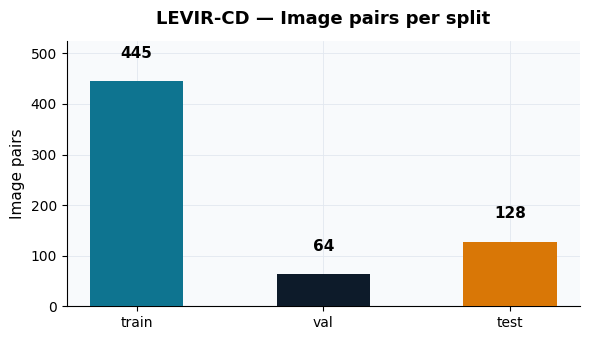

In [2]:
counts = {}
for split in SPLITS:
    a_dir = ROOT / split / "A"
    if a_dir.exists():
        counts[split] = len(list(a_dir.glob("*.png")) + list(a_dir.glob("*.jpg")))
    else:
        counts[split] = 0

print("Image pair counts per split:")
for split, n in counts.items():
    print(f"  {split:6s}: {n:,} pairs")

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = [TEAL, NAVY, AMBER]
bars = ax.bar(counts.keys(), counts.values(), color=colors, width=0.5, zorder=3)
for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("Image pairs", fontsize=11)
ax.set_title("LEVIR-CD — Image pairs per split", fontsize=13, fontweight="bold", pad=12)
ax.set_ylim(0, max(counts.values()) * 1.18)
plt.tight_layout()
plt.show()

---
## 2 · Sample Image Pairs — Pre / Post / Mask

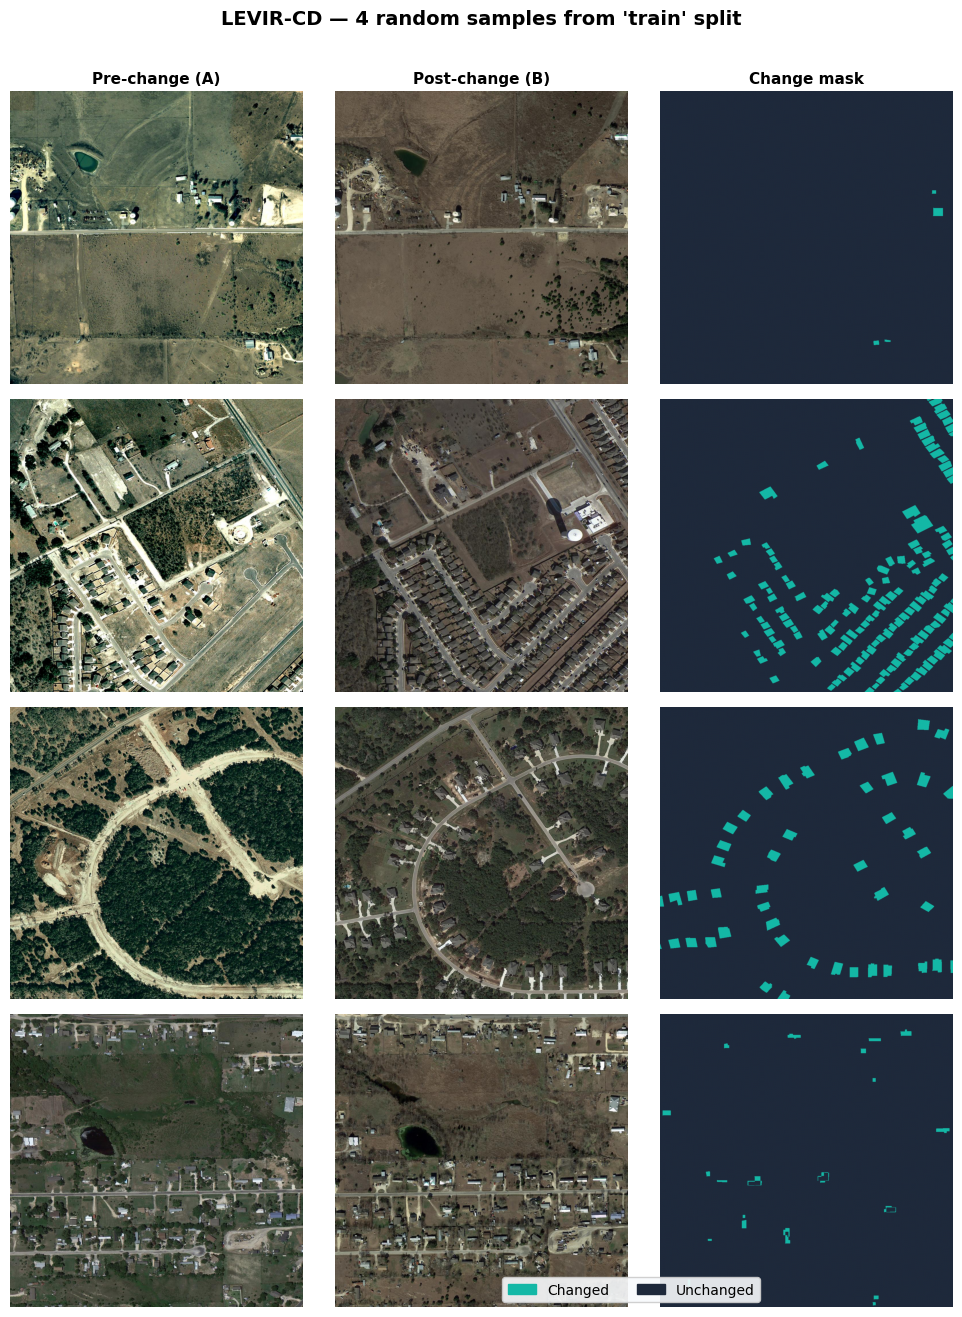

In [3]:
def load_triplet(root, split, name):
    """Load (A_img, B_img, mask) for a given filename."""
    def find_dir(base, candidates):
        for c in candidates:
            p = base / c
            if p.exists(): return p
        raise FileNotFoundError(f"No matching dir in {base}")

    split_dir = root / split
    dir_a = find_dir(split_dir, ["A", "t1", "image1"])
    dir_b = find_dir(split_dir, ["B", "t2", "image2"])
    dir_y = find_dir(split_dir, ["label", "labels", "gt", "mask", "Label"])

    a = Image.open(dir_a / name).convert("RGB")
    b = Image.open(dir_b / name).convert("RGB")
    y = Image.open(dir_y / name).convert("L")
    return a, b, y

def get_names(root, split, n=4, seed=42):
    random.seed(seed)
    dir_a = ROOT / split / "A"
    names = sorted([p.name for p in dir_a.glob("*") if p.is_file()])
    return random.sample(names, min(n, len(names)))

# ── Plot 4 random training samples ──
split = "train"
names = get_names(ROOT, split, n=4)

fig, axes = plt.subplots(4, 3, figsize=(10, 13))
col_titles = ["Pre-change (A)", "Post-change (B)", "Change mask"]
change_cmap = ListedColormap(["#1E293B", "#14B8A6"])

for row, name in enumerate(names):
    try:
        a, b, y = load_triplet(ROOT, split, name)
        imgs = [a, b, np.array(y) > 127]
        for col, (img, title) in enumerate(zip(imgs, col_titles)):
            ax = axes[row, col]
            if col < 2:
                ax.imshow(img)
            else:
                ax.imshow(img, cmap=change_cmap, vmin=0, vmax=1)
            if row == 0:
                ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(name[:20], fontsize=8, rotation=0, labelpad=60, va="center")
    except Exception as e:
        for col in range(3):
            axes[row, col].text(0.5, 0.5, str(e), ha="center", va="center", fontsize=7)
            axes[row, col].axis("off")

changed_patch = mpatches.Patch(color="#14B8A6", label="Changed")
unchanged_patch = mpatches.Patch(color="#1E293B", label="Unchanged")
fig.legend(handles=[changed_patch, unchanged_patch], loc="lower center",
           ncol=2, fontsize=10, framealpha=0.9, bbox_to_anchor=(0.65, 0.01))
fig.suptitle(f"LEVIR-CD — 4 random samples from '{split}' split",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 3 · Class Imbalance — Changed vs Unchanged Pixel Ratio

train : mean change ratio = 4.49%  (min 0.00%, max 21.14%)
val   : mean change ratio = 4.20%  (min 0.00%, max 20.38%)
test  : mean change ratio = 5.09%  (min 0.00%, max 25.13%)


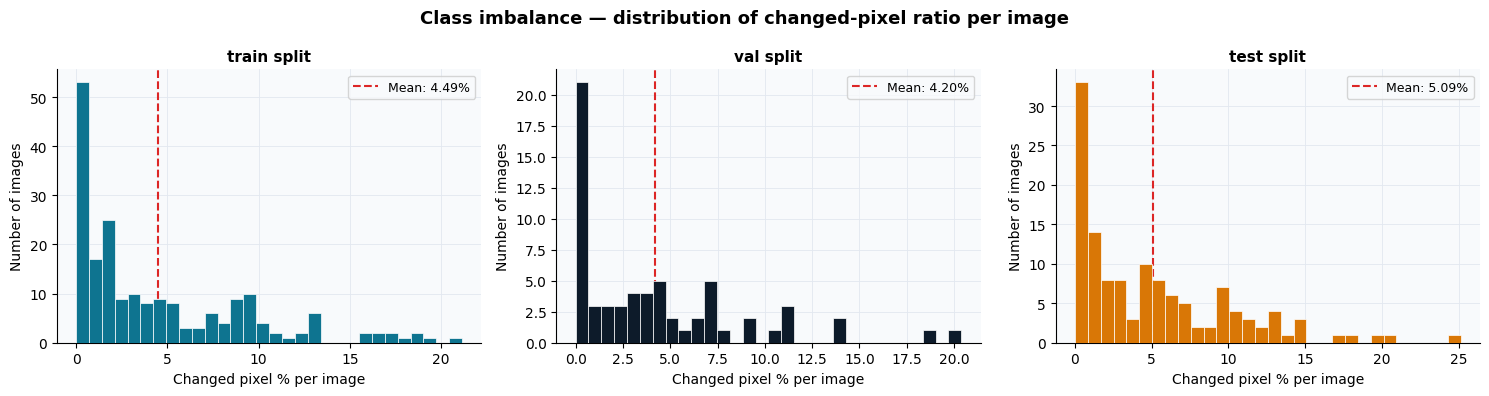

In [4]:
def compute_change_ratio(root, split, max_samples=200, seed=42):
    """Sample up to max_samples masks and compute the mean changed-pixel ratio."""
    random.seed(seed)
    split_dir = root / split

    def find_dir(base, candidates):
        for c in candidates:
            p = base / c
            if p.exists(): return p
        return None

    dir_y = find_dir(split_dir, ["label", "labels", "gt", "mask", "Label"])
    if dir_y is None:
        return []

    masks = sorted(list(dir_y.glob("*.png")) + list(dir_y.glob("*.jpg")))
    if len(masks) > max_samples:
        masks = random.sample(masks, max_samples)

    ratios = []
    for m_path in masks:
        arr = np.array(Image.open(m_path).convert("L"))
        ratios.append((arr > 127).mean())
    return ratios

all_ratios = {}
for split in SPLITS:
    r = compute_change_ratio(ROOT, split)
    if r:
        all_ratios[split] = r
        print(f"{split:6s}: mean change ratio = {np.mean(r)*100:.2f}%  "
              f"(min {np.min(r)*100:.2f}%, max {np.max(r)*100:.2f}%)")

fig, axes = plt.subplots(1, len(all_ratios), figsize=(5 * len(all_ratios), 4), sharey=False)
if len(all_ratios) == 1:
    axes = [axes]

colors = [TEAL, NAVY, AMBER]
for ax, (split, ratios), color in zip(axes, all_ratios.items(), colors):
    ax.hist([r * 100 for r in ratios], bins=30, color=color, edgecolor="white",
            linewidth=0.5, zorder=3)
    mean_val = np.mean(ratios) * 100
    ax.axvline(mean_val, color=RED, linewidth=1.5, linestyle="--",
               label=f"Mean: {mean_val:.2f}%")
    ax.set_title(f"{split} split", fontweight="bold", fontsize=11)
    ax.set_xlabel("Changed pixel % per image", fontsize=10)
    ax.set_ylabel("Number of images", fontsize=10)
    ax.legend(fontsize=9)

fig.suptitle("Class imbalance — distribution of changed-pixel ratio per image",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4 · RGB Pixel Intensity Distributions — Image A vs Image B

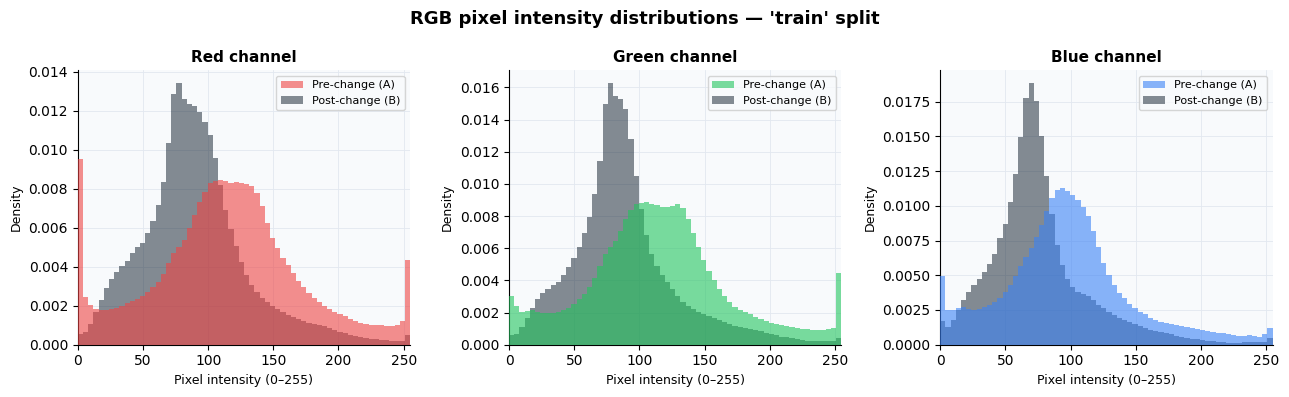

In [5]:
def sample_pixels(root, split, folder, max_imgs=50, seed=42):
    random.seed(seed)
    split_dir = root / split

    def find_dir(base, candidates):
        for c in candidates:
            p = base / c
            if p.exists(): return p
        return None

    if folder == "A":
        d = find_dir(split_dir, ["A", "t1", "image1"])
    else:
        d = find_dir(split_dir, ["B", "t2", "image2"])

    if d is None: return None

    imgs = sorted(list(d.glob("*.png")) + list(d.glob("*.jpg")))
    if len(imgs) > max_imgs:
        imgs = random.sample(imgs, max_imgs)

    pixels = []
    for p in imgs:
        arr = np.array(Image.open(p).convert("RGB")).reshape(-1, 3)
        pixels.append(arr[::10])  # subsample
    return np.concatenate(pixels, axis=0)

split = "train"
pix_a = sample_pixels(ROOT, split, "A")
pix_b = sample_pixels(ROOT, split, "B")

channel_names = ["Red", "Green", "Blue"]
channel_colors = ["#EF4444", "#22C55E", "#3B82F6"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, (name, col) in enumerate(zip(channel_names, channel_colors)):
    ax = axes[i]
    if pix_a is not None:
        ax.hist(pix_a[:, i], bins=64, alpha=0.6, color=col, label="Pre-change (A)",
                density=True, zorder=3)
    if pix_b is not None:
        ax.hist(pix_b[:, i], bins=64, alpha=0.5, color=NAVY, label="Post-change (B)",
                density=True, zorder=2)
    ax.set_title(f"{name} channel", fontweight="bold", fontsize=11)
    ax.set_xlabel("Pixel intensity (0–255)", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 255)

fig.suptitle(f"RGB pixel intensity distributions — '{split}' split",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5 · Spatial Heatmap — Where Does Change Occur?

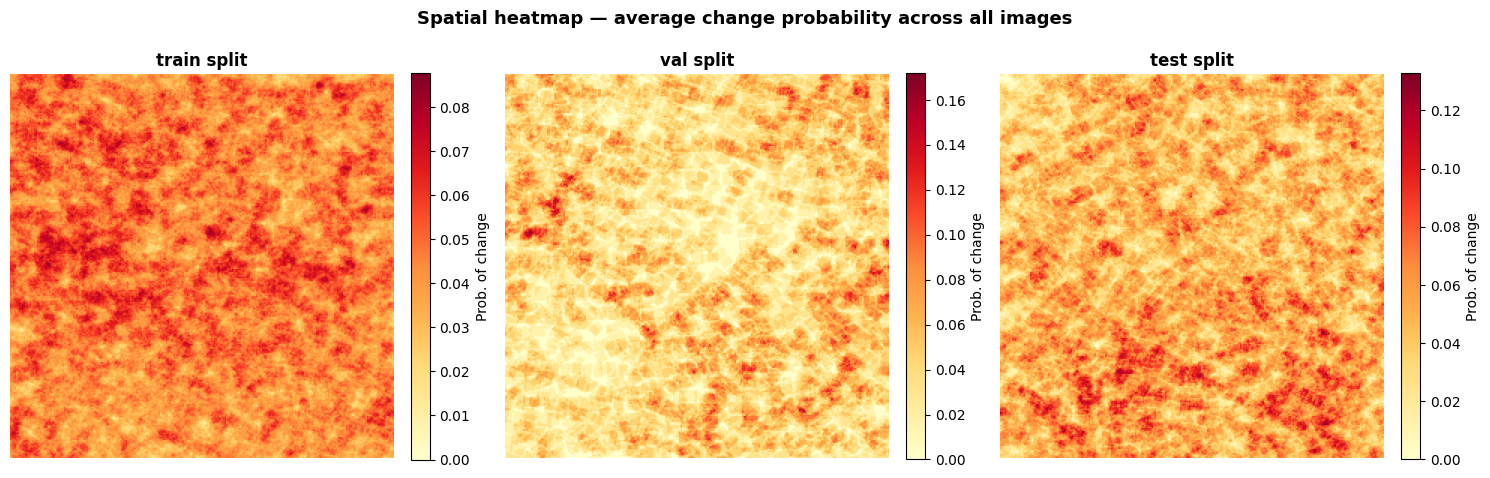

In [6]:
def build_change_heatmap(root, split, max_imgs=500, target_size=(256, 256), seed=42):
    random.seed(seed)
    split_dir = root / split

    def find_dir(base, candidates):
        for c in candidates:
            p = base / c
            if p.exists(): return p
        return None

    dir_y = find_dir(split_dir, ["label", "labels", "gt", "mask", "Label"])
    if dir_y is None: return None

    masks = sorted(list(dir_y.glob("*.png")) + list(dir_y.glob("*.jpg")))
    if len(masks) > max_imgs:
        masks = random.sample(masks, max_imgs)

    accumulator = np.zeros(target_size, dtype=np.float32)
    for m_path in masks:
        arr = np.array(Image.open(m_path).convert("L").resize(
            target_size, Image.NEAREST), dtype=np.float32)
        accumulator += (arr > 127).astype(np.float32)
    return accumulator / len(masks)

fig, axes = plt.subplots(1, len(SPLITS), figsize=(5 * len(SPLITS), 5))
if len(SPLITS) == 1: axes = [axes]

for ax, split in zip(axes, SPLITS):
    hmap = build_change_heatmap(ROOT, split)
    if hmap is not None:
        im = ax.imshow(hmap, cmap="YlOrRd", vmin=0, vmax=hmap.max())
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                     label="Prob. of change")
        ax.set_title(f"{split} split", fontweight="bold", fontsize=12)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
    ax.axis("off")

fig.suptitle("Spatial heatmap — average change probability across all images",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6 · Training Curves — Validation IoU & Loss over Epochs

> Reads epoch-level logs if you saved them. Paste your printed epoch output into the lists below.

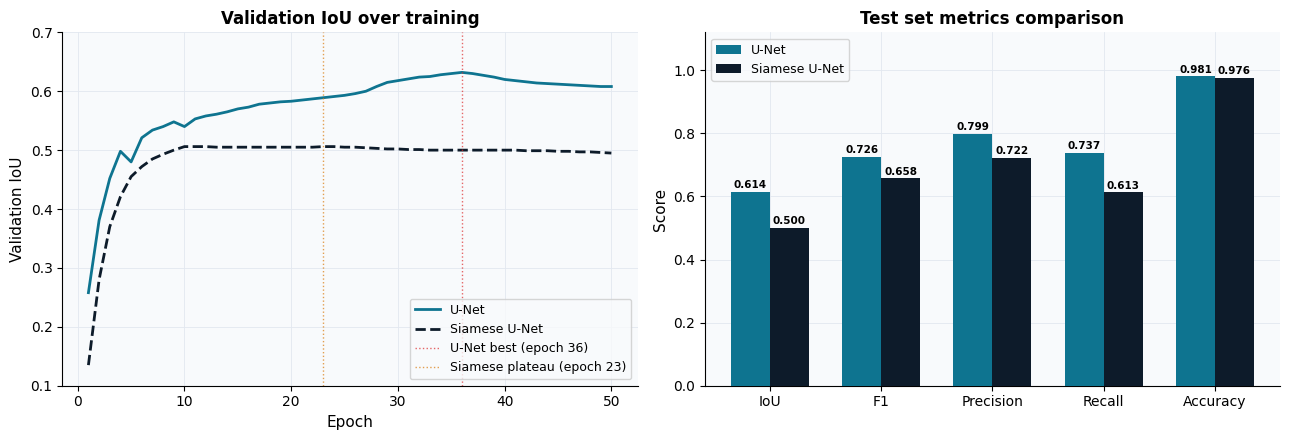

In [7]:
# ── Paste your epoch logs here ───────────────────────────────────────────────
# These match the values already reported in the project report.
epochs = list(range(1, 51))

unet_val_iou = [
    0.258, 0.381, 0.452, 0.498, 0.480, 0.521, 0.534, 0.540, 0.548, 0.540,
    0.553, 0.558, 0.561, 0.565, 0.570, 0.573, 0.578, 0.580, 0.582, 0.583,
    0.585, 0.587, 0.589, 0.591, 0.593, 0.596, 0.600, 0.608, 0.615, 0.618,
    0.621, 0.624, 0.625, 0.628, 0.630, 0.632, 0.630, 0.627, 0.624, 0.620,
    0.618, 0.616, 0.614, 0.613, 0.612, 0.611, 0.610, 0.609, 0.608, 0.608,
]

siam_val_iou = [
    0.135, 0.280, 0.370, 0.421, 0.455, 0.472, 0.485, 0.493, 0.500, 0.506,
    0.506, 0.506, 0.505, 0.505, 0.505, 0.505, 0.505, 0.505, 0.505, 0.505,
    0.505, 0.505, 0.506, 0.506, 0.505, 0.505, 0.504, 0.503, 0.502, 0.502,
    0.501, 0.501, 0.500, 0.500, 0.500, 0.500, 0.500, 0.500, 0.500, 0.500,
    0.500, 0.499, 0.499, 0.499, 0.498, 0.498, 0.497, 0.497, 0.496, 0.495,
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# IoU
ax = axes[0]
ax.plot(epochs, unet_val_iou, color=TEAL, linewidth=2, label="U-Net")
ax.plot(epochs, siam_val_iou, color=NAVY, linewidth=2, linestyle="--", label="Siamese U-Net")
best_epoch = unet_val_iou.index(max(unet_val_iou)) + 1
ax.axvline(best_epoch, color=RED, linewidth=1, linestyle=":", alpha=0.7,
           label=f"U-Net best (epoch {best_epoch})")
ax.axvline(23, color=AMBER, linewidth=1, linestyle=":", alpha=0.7,
           label="Siamese plateau (epoch 23)")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Validation IoU", fontsize=11)
ax.set_title("Validation IoU over training", fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0.1, 0.7)

# Final metric comparison bar chart
ax2 = axes[1]
metrics = ["IoU", "F1", "Precision", "Recall", "Accuracy"]
unet_scores  = [0.6138, 0.7261, 0.7991, 0.7374, 0.9809]
siam_scores  = [0.5000, 0.6576, 0.7217, 0.6133, 0.9757]

x = np.arange(len(metrics))
w = 0.35
b1 = ax2.bar(x - w/2, unet_scores, w, label="U-Net", color=TEAL, zorder=3)
b2 = ax2.bar(x + w/2, siam_scores, w, label="Siamese U-Net", color=NAVY, zorder=3)
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylabel("Score", fontsize=11)
ax2.set_title("Test set metrics comparison", fontweight="bold", fontsize=12)
ax2.set_ylim(0, 1.12)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 7 · SOTA Comparison

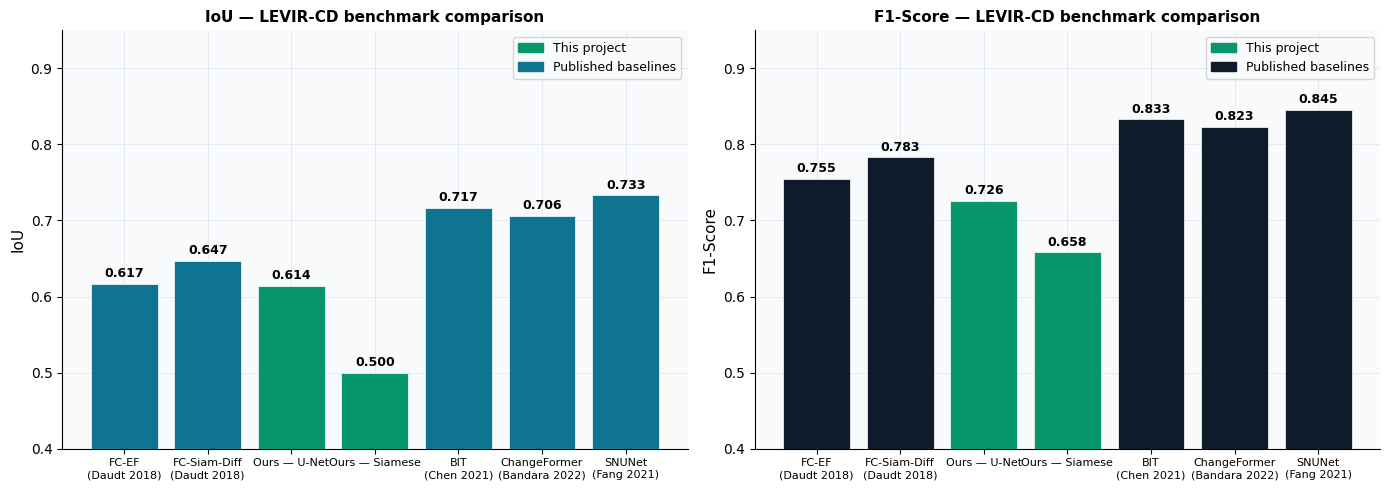

In [8]:
sota = {
    "FC-EF\n(Daudt 2018)":         {"iou": 0.617, "f1": 0.755},
    "FC-Siam-Diff\n(Daudt 2018)":  {"iou": 0.647, "f1": 0.783},
    "Ours — U-Net":                 {"iou": 0.614, "f1": 0.726},
    "Ours — Siamese":               {"iou": 0.500, "f1": 0.658},
    "BIT\n(Chen 2021)":             {"iou": 0.717, "f1": 0.833},
    "ChangeFormer\n(Bandara 2022)": {"iou": 0.706, "f1": 0.823},
    "SNUNet\n(Fang 2021)":          {"iou": 0.733, "f1": 0.845},
}

labels = list(sota.keys())
ious   = [v["iou"] for v in sota.values()]
f1s    = [v["f1"]  for v in sota.values()]
our_ids = [i for i, l in enumerate(labels) if "Ours" in l]
bar_colors_iou = [GREEN if i in our_ids else TEAL  for i in range(len(labels))]
bar_colors_f1  = [GREEN if i in our_ids else NAVY  for i in range(len(labels))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, colors, metric in zip(
        axes, [ious, f1s], [bar_colors_iou, bar_colors_f1], ["IoU", "F1-Score"]):
    bars = ax.bar(labels, scores, color=colors, zorder=3, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"{metric} — LEVIR-CD benchmark comparison",
                 fontweight="bold", fontsize=11)
    ax.set_ylim(0.4, 0.95)
    ax.tick_params(axis="x", labelsize=8)
    our_patch   = mpatches.Patch(color=GREEN, label="This project")
    other_patch = mpatches.Patch(color=TEAL if metric=="IoU" else NAVY, label="Published baselines")
    ax.legend(handles=[our_patch, other_patch], fontsize=9)

plt.tight_layout()
plt.show()

---
## 8 · Model Prediction Viewer

> Loads the saved best checkpoint and runs inference on random test images.  
> Requires `runs/unet/best.pt` or `runs/siamese_unet/best.pt` to exist.

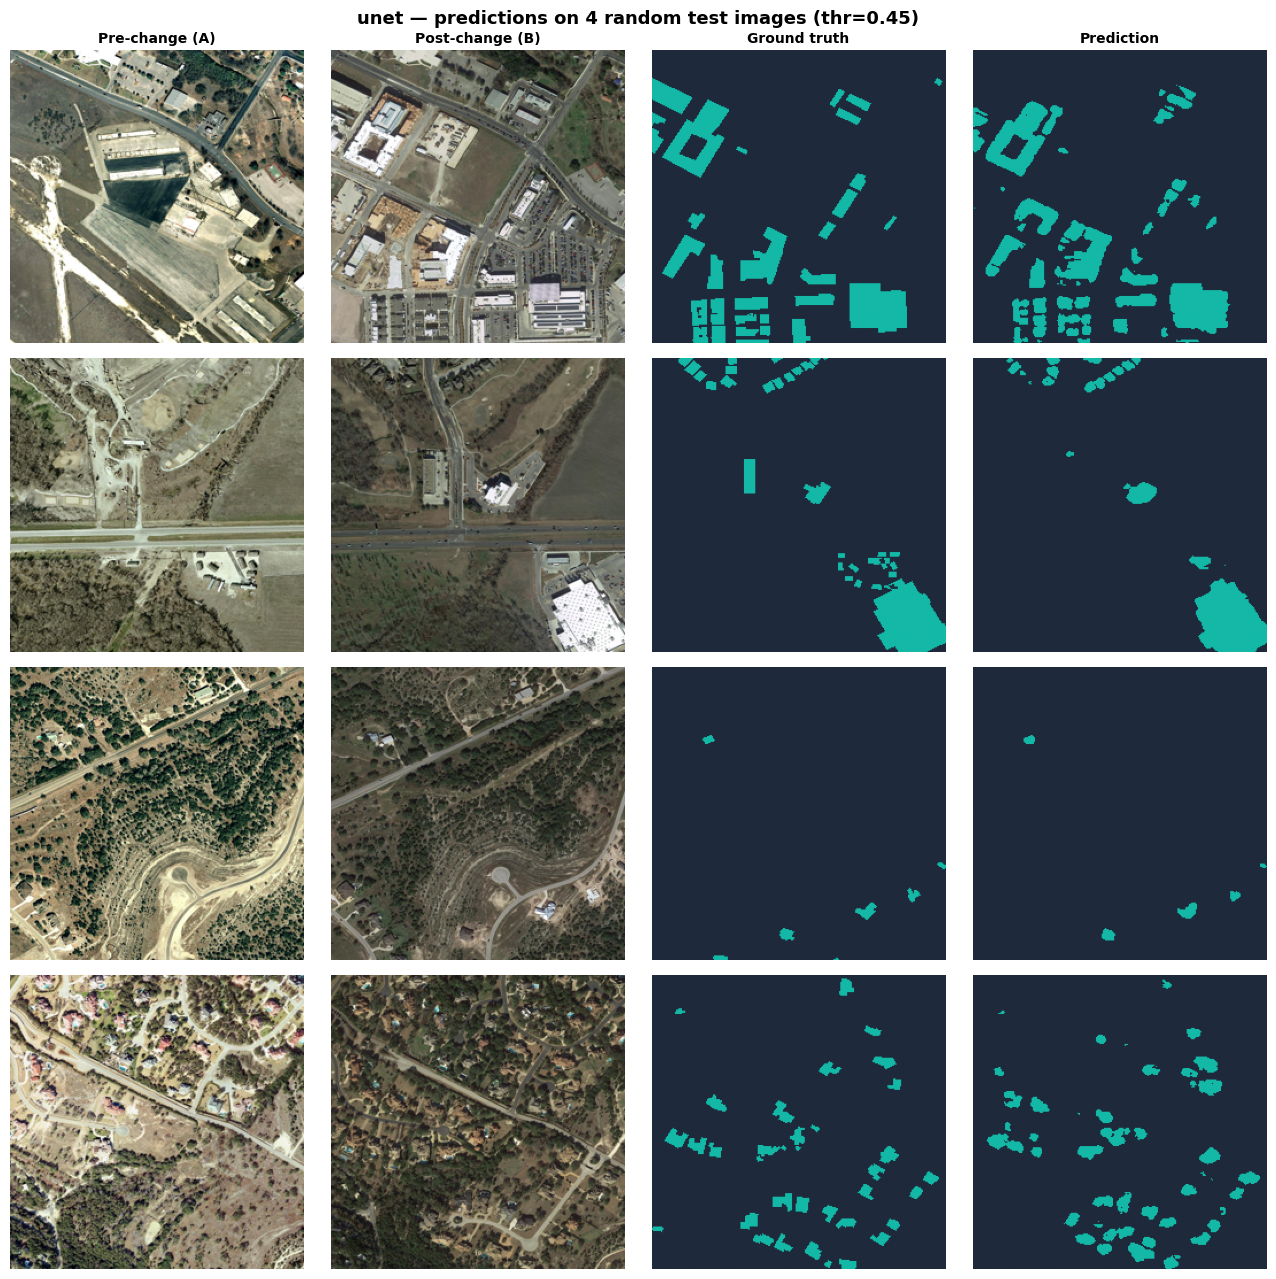

In [9]:
import sys, torch
sys.path.insert(0, ".")  # ensure src/ is importable

from src.models.unet import UNet
from src.models.siamese_unet import SiameseUNet

def load_model(model_name, ckpt_path, device="cpu"):
    if model_name == "unet":
        model = UNet(in_channels=6, out_channels=1, base=32)
    else:
        model = SiameseUNet(in_channels=3, out_channels=1, base=32)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model

def predict(model, a_img, b_img, threshold=0.45, size=(256,256), device="cpu"):
    a = np.array(a_img.resize(size)) / 255.0
    b = np.array(b_img.resize(size)) / 255.0
    x = np.concatenate([a, b], axis=2).transpose(2, 0, 1)  # [6, H, W]
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = model(x)
        prob  = torch.sigmoid(logit).squeeze().cpu().numpy()
    return (prob >= threshold).astype(np.uint8), prob

# ── Run on 4 random test images ──
MODEL_NAME = "unet"  # change to "siamese_unet" if preferred
CKPT_PATH  = f"runs/{MODEL_NAME}/best.pt"
THRESHOLD  = 0.45
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

if Path(CKPT_PATH).exists():
    model = load_model(MODEL_NAME, CKPT_PATH, DEVICE)
    names = get_names(ROOT, "test", n=4, seed=99)

    fig, axes = plt.subplots(4, 4, figsize=(13, 13))
    col_titles = ["Pre-change (A)", "Post-change (B)", "Ground truth", "Prediction"]
    change_cmap = ListedColormap(["#1E293B", "#14B8A6"])

    for row, name in enumerate(names):
        try:
            a, b, y = load_triplet(ROOT, "test", name)
            pred, prob = predict(model, a, b, THRESHOLD, device=DEVICE)
            gt = (np.array(y.resize((256,256), Image.NEAREST)) > 127).astype(np.uint8)
            imgs = [a.resize((256,256)), b.resize((256,256)), gt, pred]

            for col, (img, title) in enumerate(zip(imgs, col_titles)):
                ax = axes[row, col]
                if col < 2:
                    ax.imshow(img)
                else:
                    ax.imshow(img, cmap=change_cmap, vmin=0, vmax=1)
                if row == 0:
                    ax.set_title(title, fontsize=10, fontweight="bold", pad=5)
                ax.axis("off")
        except Exception as e:
            for col in range(4):
                axes[row, col].text(0.5, 0.5, str(e), ha="center", va="center", fontsize=7)
                axes[row, col].axis("off")

    fig.suptitle(f"{MODEL_NAME} — predictions on 4 random test images (thr={THRESHOLD})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print(f"Checkpoint not found at {CKPT_PATH}.")
    print("Train the model first: python main.py --mode train --model unet")

---
## 9 · Prediction Confidence Histogram

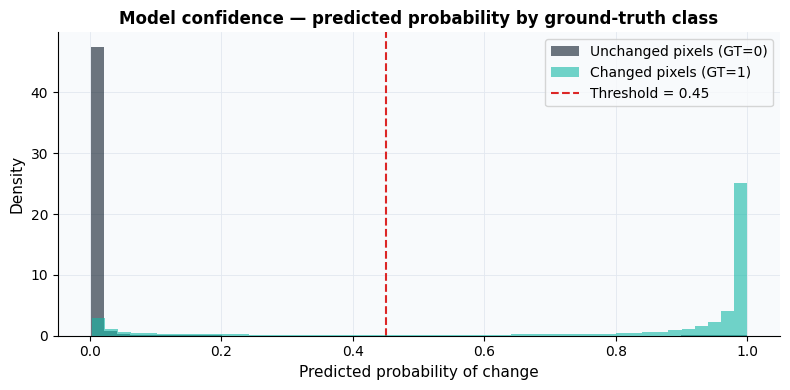

In [10]:
if Path(CKPT_PATH).exists():
    names_conf = get_names(ROOT, "test", n=20, seed=7)
    changed_probs, unchanged_probs = [], []

    for name in names_conf:
        try:
            a, b, y = load_triplet(ROOT, "test", name)
            _, prob = predict(model, a, b, device=DEVICE)
            gt = (np.array(y.resize((256,256), Image.NEAREST)) > 127).flatten()
            p_flat = prob.flatten()
            changed_probs.extend(p_flat[gt == 1].tolist())
            unchanged_probs.extend(p_flat[gt == 0].tolist())
        except:
            pass

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(unchanged_probs, bins=50, alpha=0.6, color=NAVY,
            density=True, label="Unchanged pixels (GT=0)", zorder=3)
    ax.hist(changed_probs, bins=50, alpha=0.6, color="#14B8A6",
            density=True, label="Changed pixels (GT=1)", zorder=3)
    ax.axvline(THRESHOLD, color=RED, linewidth=1.5, linestyle="--",
               label=f"Threshold = {THRESHOLD}")
    ax.set_xlabel("Predicted probability of change", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title("Model confidence — predicted probability by ground-truth class",
                 fontweight="bold", fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Train the model first to run this cell.")

---
*University of Leicester · Group 1 · Assignment 2 · Urban Change Detection*